In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Data Cleaning & Analysis

In [2]:
df_batting = pd.read_csv('/content/sample_data/ODI data.csv')
df_batting.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   2500 non-null   int64  
 1   Player       2500 non-null   object 
 2   Span         2500 non-null   object 
 3   Mat          2500 non-null   int64  
 4   Inns         2500 non-null   object 
 5   NO           2500 non-null   object 
 6   Runs         2500 non-null   object 
 7   HS           2500 non-null   object 
 8   Ave          2500 non-null   object 
 9   BF           2500 non-null   object 
 10  SR           2500 non-null   object 
 11  100          2500 non-null   object 
 12  50           2500 non-null   object 
 13  0            2500 non-null   object 
 14  Unnamed: 13  0 non-null      float64
dtypes: float64(1), int64(2), object(12)
memory usage: 293.1+ KB


In [3]:
df_batting.head()

,Unnamed: 0,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Unnamed: 13
0,0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20,NaN
1,1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15,NaN
2,2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20,NaN
3,3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.2,28,68,34,NaN
4,4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28,NaN


we can check for the null values

In [4]:
df_batting.isnull().sum()

,0
Unnamed: 0,0
Player,0
Span,0
Mat,0
Inns,0
NO,0
Runs,0
HS,0
Ave,0
BF,0


In [5]:
df1=df_batting.drop(columns=['Unnamed: 13','Unnamed: 0'])
df1.describe(include='all')


,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0
count,2500,2500,2500.000000,2500,2500,2500,2500,2500,2500,2500,2500,2500,2500
unique,2499,566,NaN,218,61,941,344,1235,1054,1720,30,70,30
top,Raqibul Hasan (BDESH),2019-2019,NaN,1,0,0,0,-,11,0.00,0,0,0
freq,2,101,NaN,281,736,65,44,130,31,57,2096,1550,918
mean,NaN,NaN,37.161600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,58.885075,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,13.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,43.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
def year_start(x):
  d= x.split('-')
  return d[0]

def year_end(x):
  d= x.split('-')
  return d[1]

df1['Span']=df1['Span'].astype('str')
df1['Year_start']=df1['Span'].apply(year_start)
df1['Year_end']=df1['Span'].apply(year_end)
df2=df1.drop(columns=['Span'])

df2.head()

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Year_start,Year_end
0,SR Tendulkar (INDIA),463,452,41,18426,200*,44.83,21367,86.23,49,96,20,1989,2012
1,KC Sangakkara (Asia/ICC/SL),404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015
2,RT Ponting (AUS/ICC),375,365,39,13704,164,42.03,17046,80.39,30,82,20,1995,2012
3,ST Jayasuriya (Asia/SL),445,433,18,13430,189,32.36,14725,91.2,28,68,34,1989,2011
4,DPMD Jayawardene (Asia/SL),448,418,39,12650,144,33.37,16020,78.96,19,77,28,1998,2015


In [7]:
df2.head(10)

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Year_start,Year_end
0,SR Tendulkar (INDIA),463,452,41,18426,200*,44.83,21367,86.23,49,96,20,1989,2012
1,KC Sangakkara (Asia/ICC/SL),404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015
2,RT Ponting (AUS/ICC),375,365,39,13704,164,42.03,17046,80.39,30,82,20,1995,2012
3,ST Jayasuriya (Asia/SL),445,433,18,13430,189,32.36,14725,91.2,28,68,34,1989,2011
4,DPMD Jayawardene (Asia/SL),448,418,39,12650,144,33.37,16020,78.96,19,77,28,1998,2015
5,Inzamam-ul-Haq (Asia/PAK),378,350,53,11739,137*,39.52,15812,74.24,10,83,20,1991,2007
6,V Kohli (INDIA),242,233,39,11609,183,59.84,12445,93.28,43,55,13,2008,2019
7,JH Kallis (Afr/ICC/SA),328,314,53,11579,139,44.36,15885,72.89,17,86,17,1996,2014
8,SC Ganguly (Asia/INDIA),311,300,23,11363,183,41.02,15416,73.7,22,72,16,1992,2007
9,R Dravid (Asia/ICC/INDIA),344,318,40,10889,153,39.16,15284,71.24,12,83,13,1996,2011


In [8]:
print("Max start year:" , df2['Year_start'].max())
print("Min start year:" ,df2['Year_start'].min())
print("Max end year:",df2['Year_end'].max())
print("Max end year:", df2['Year_end'].min())

Max start year: 2019
Min start year: 1971
Max end year: 2019
Max end year: 1971


From this we can understand that we have players data who played from 1971  and the players who played till 2019.

In [9]:
df2.dtypes

,0
Player,object
Mat,int64
Inns,object
NO,object
Runs,object
HS,object
Ave,object
BF,object
SR,object
100,object


changing object to numeric data types

In [10]:
df2['HS']=df2['HS'].replace({'\*' : ''},regex=True)
df2.head()
df2.dtypes

,0
Player,object
Mat,int64
Inns,object
NO,object
Runs,object
HS,object
Ave,object
BF,object
SR,object
100,object


In [11]:
df2.columns

Index(['Player', 'Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'BF', 'SR', '100',
       '50', '0', 'Year_start', 'Year_end'],
      dtype='object')

In [12]:
cols=['Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'BF', 'SR', '100',
       '50', '0', 'Year_start', 'Year_end']

df_final=df2[cols].apply(pd.to_numeric,errors='coerce')
df_final['Player']=df2['Player'].astype('str')


df_final.dtypes

,0
Mat,int64
Inns,float64
NO,float64
Runs,float64
HS,float64
Ave,float64
BF,float64
SR,float64
100,float64
50,float64


In [13]:
df_final.head()

,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Year_start,Year_end,Player
0,463,452.0,41.0,18426.0,200.0,44.83,21367.0,86.23,49.0,96.0,20.0,1989,2012,SR Tendulkar (INDIA)
1,404,380.0,41.0,14234.0,169.0,41.98,18048.0,78.86,25.0,93.0,15.0,2000,2015,KC Sangakkara (Asia/ICC/SL)
2,375,365.0,39.0,13704.0,164.0,42.03,17046.0,80.39,30.0,82.0,20.0,1995,2012,RT Ponting (AUS/ICC)
3,445,433.0,18.0,13430.0,189.0,32.36,14725.0,91.20,28.0,68.0,34.0,1989,2011,ST Jayasuriya (Asia/SL)
4,448,418.0,39.0,12650.0,144.0,33.37,16020.0,78.96,19.0,77.0,28.0,1998,2015,DPMD Jayawardene (Asia/SL)


In [14]:
df_final.columns

Index(['Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'BF', 'SR', '100', '50', '0',
       'Year_start', 'Year_end', 'Player'],
      dtype='object')

In [15]:
df_final=df_final[['Player','Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'BF', 'SR', '100', '50', '0',
       'Year_start', 'Year_end']]
df_final.head()

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Year_start,Year_end
0,SR Tendulkar (INDIA),463,452.0,41.0,18426.0,200.0,44.83,21367.0,86.23,49.0,96.0,20.0,1989,2012
1,KC Sangakkara (Asia/ICC/SL),404,380.0,41.0,14234.0,169.0,41.98,18048.0,78.86,25.0,93.0,15.0,2000,2015
2,RT Ponting (AUS/ICC),375,365.0,39.0,13704.0,164.0,42.03,17046.0,80.39,30.0,82.0,20.0,1995,2012
3,ST Jayasuriya (Asia/SL),445,433.0,18.0,13430.0,189.0,32.36,14725.0,91.20,28.0,68.0,34.0,1989,2011
4,DPMD Jayawardene (Asia/SL),448,418.0,39.0,12650.0,144.0,33.37,16020.0,78.96,19.0,77.0,28.0,1998,2015


Check null values after changing the data type

In [16]:
def missing_value(df):
    null_values=df.isnull().sum()
    percent=df.isnull().sum()/df.isnull().count()*100
    actual_missing_values=pd.concat([null_values,percent],axis=1,keys=['value','Percentage'])
    print(actual_missing_values)


missing_value(df_final)


            value  Percentage
Player          0        0.00
Mat             0        0.00
Inns           10        0.40
NO             10        0.40
Runs           10        0.40
HS             10        0.40
Ave           130        5.20
BF             10        0.40
SR             19        0.76
100            10        0.40
50             10        0.40
0              10        0.40
Year_start      0        0.00
Year_end        0        0.00


In [17]:
df_null=df_final[df_final[['Inns','NO','Runs','HS','BF',]].isnull().any(axis=1)]
df_null.reset_index()
df_null

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Year_start,Year_end
2490,Aamer Hameed (PAK),2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1977,1978
2491,Abdur Rauf (PAK),4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008,2008
2492,Abu Jayed (BDESH),2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019,2019
2493,FS Ahangama (SL),1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1985,1985
2494,GW Aldridge (NZ),2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011
2495,ZS Ansari (ENG),1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,2015
2496,Ariful Haque (BDESH),1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018,2018
2497,Ashfaq Ahmed (PAK),3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1994,1994
2498,MD Bailey (NZ),1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1998,1998
2499,GR Beard (AUS),2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1981,1981


In [18]:
df_final.shape

(2500, 14)

After dropping the null value rows and changing the types we have 2490 rows and 14 columns . Lets start our Analysis

#Batting Analysis

In [19]:
df_final.head()

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Year_start,Year_end
0,SR Tendulkar (INDIA),463,452.0,41.0,18426.0,200.0,44.83,21367.0,86.23,49.0,96.0,20.0,1989,2012
1,KC Sangakkara (Asia/ICC/SL),404,380.0,41.0,14234.0,169.0,41.98,18048.0,78.86,25.0,93.0,15.0,2000,2015
2,RT Ponting (AUS/ICC),375,365.0,39.0,13704.0,164.0,42.03,17046.0,80.39,30.0,82.0,20.0,1995,2012
3,ST Jayasuriya (Asia/SL),445,433.0,18.0,13430.0,189.0,32.36,14725.0,91.20,28.0,68.0,34.0,1989,2011
4,DPMD Jayawardene (Asia/SL),448,418.0,39.0,12650.0,144.0,33.37,16020.0,78.96,19.0,77.0,28.0,1998,2015


In [20]:
df_final.describe()

,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Year_start,Year_end
count,2500.000000,2490.000000,2490.000000,2490.000000,2490.000000,2370.000000,2490.000000,2481.000000,2490.000000,2490.000000,2490.000000,2500.000000,2500.000000
mean,37.161600,29.605622,5.496787,676.234538,47.907631,18.280996,905.231325,63.577731,0.725703,3.570281,2.474297,1999.912800,2004.137600
std,58.885075,51.380511,9.362150,1616.848599,44.028374,12.808239,2062.373445,26.810820,2.937931,9.872351,3.843402,13.217226,12.958373
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1971.000000,1971.000000
25%,4.000000,3.000000,0.000000,22.000000,12.250000,8.500000,43.000000,49.010000,0.000000,0.000000,0.000000,1991.000000,1996.000000
50%,13.000000,10.000000,2.000000,100.500000,34.000000,16.330000,165.000000,64.230000,0.000000,0.000000,1.000000,2003.000000,2007.000000
75%,43.000000,31.000000,6.000000,479.500000,72.000000,25.622500,671.750000,77.880000,0.000000,2.000000,3.000000,2010.000000,2016.000000
max,463.000000,452.000000,84.000000,18426.000000,264.000000,145.000000,21367.000000,328.570000,49.000000,96.000000,34.000000,2019.000000,2019.000000


In [21]:
top_runscorers=df_final.sort_values(by=['Runs'],ascending=False).head(10)
top_average=df_final.sort_values(by=['Ave'],ascending=False).head(10)
top_100=df_final.sort_values(by=['100'],ascending=False).head(10)
top_50=df_final.sort_values(by=['50'],ascending=False).head(10)

<Axes: title={'center': 'Top Players with most 50'}, xlabel='Player', ylabel='50'>

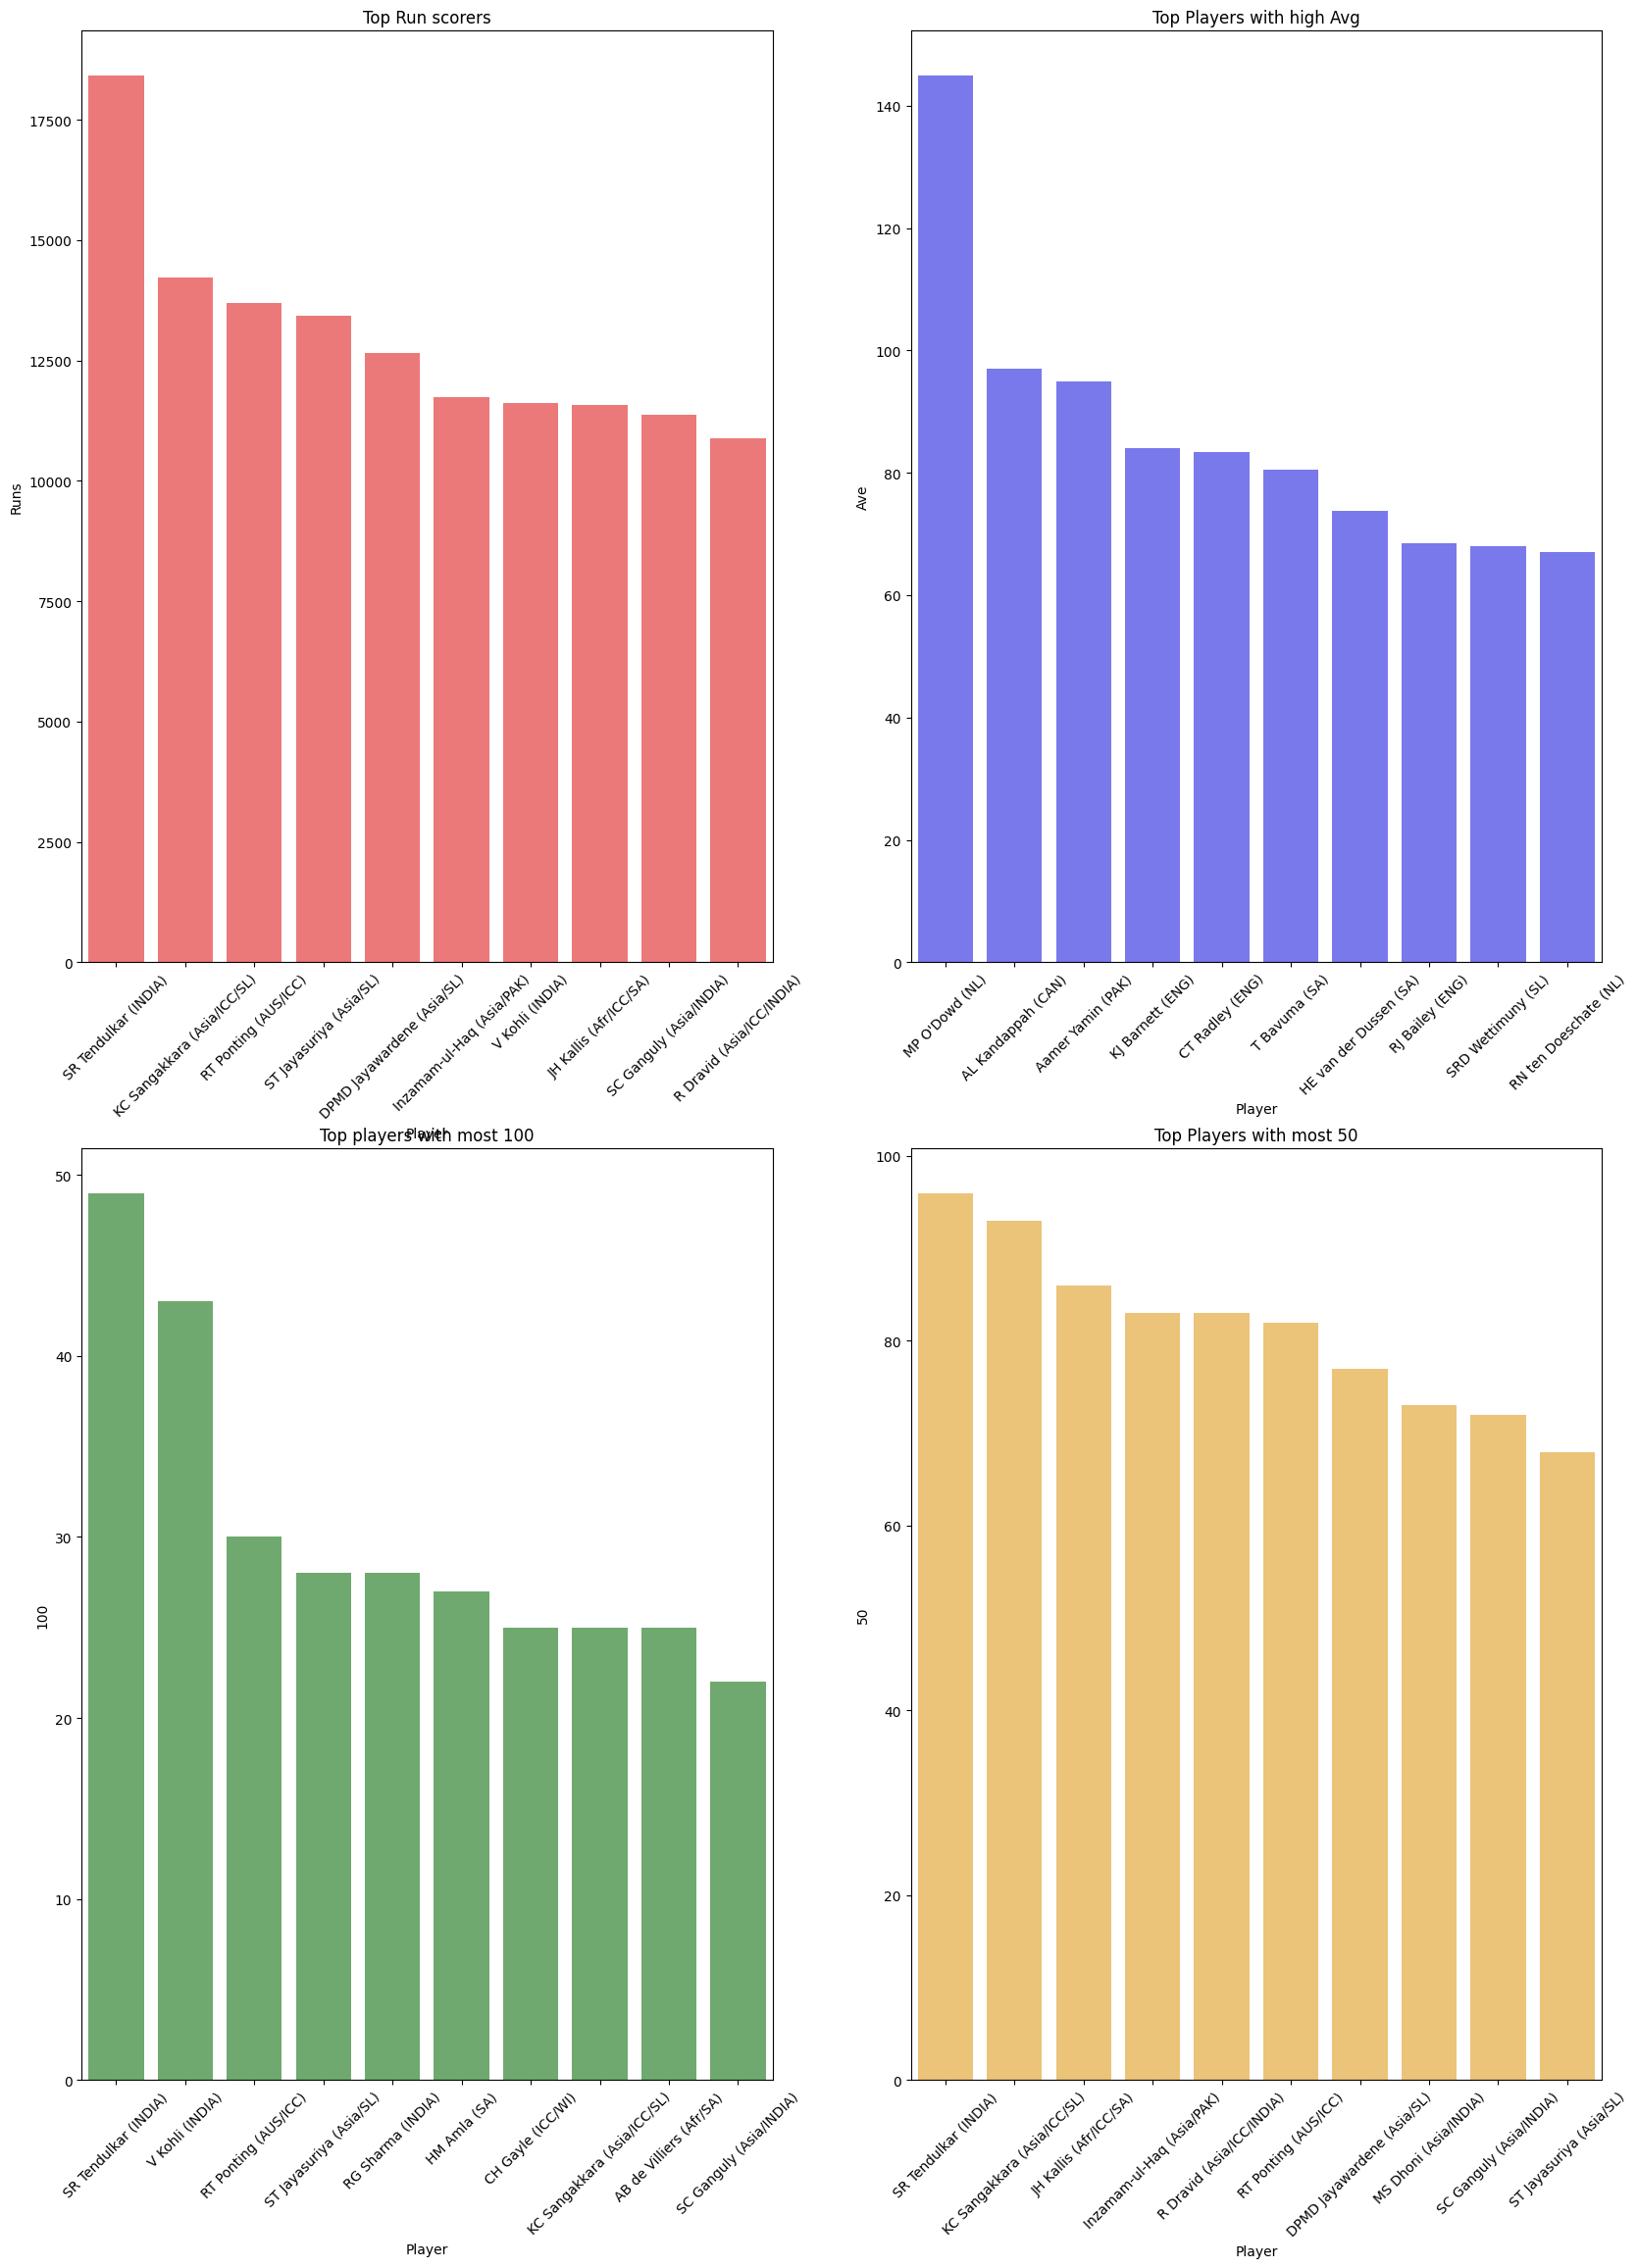

In [22]:
fig,axes= plt.subplots(2,2,figsize=(20,10))
fig.subplots_adjust(top=2.2)
plt.subplot(2,2,1)
plt.xticks(rotation=45)
plt.title('Top Run scorers')
sns.barplot(x='Player',y='Runs',data=top_runscorers,color='Red',alpha=0.6)
plt.subplot(2,2,2)
plt.xticks(rotation=45)
plt.title('Top Players with high Avg')
sns.barplot(x='Player',y='Ave',data=top_average,color='Blue',alpha=0.6)
plt.subplot(2,2,3)
plt.xticks(rotation=45)
plt.title('Top players with most 100')
sns.barplot(x='Player',y='100',data=top_100, color='Green',alpha=0.6)
plt.subplot(2,2,4)
plt.xticks(rotation=45)
plt.title('Top Players with most 50')
sns.barplot(x='Player',y='50',data=top_50,color='Orange',alpha=0.6)


Here we can clearly see that the players name got displayed based on the max runs scored , max 100 , max 50 scored.
But the max avg is not displayed for the players who played more number of matches.

In [23]:
top_players=df_final.sort_values(by=['Runs'],ascending=False)
top_ave=df_final['Ave']>40
top_players=top_players[top_ave]
top_players.head(10)

<ipython-input-23-24d359ff1b19>:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  top_players=top_players[top_ave]


,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Year_start,Year_end
0,SR Tendulkar (INDIA),463,452.0,41.0,18426.0,200.0,44.83,21367.0,86.23,49.0,96.0,20.0,1989,2012
1,KC Sangakkara (Asia/ICC/SL),404,380.0,41.0,14234.0,169.0,41.98,18048.0,78.86,25.0,93.0,15.0,2000,2015
2,RT Ponting (AUS/ICC),375,365.0,39.0,13704.0,164.0,42.03,17046.0,80.39,30.0,82.0,20.0,1995,2012
6,V Kohli (INDIA),242,233.0,39.0,11609.0,183.0,59.84,12445.0,93.28,43.0,55.0,13.0,2008,2019
7,JH Kallis (Afr/ICC/SA),328,314.0,53.0,11579.0,139.0,44.36,15885.0,72.89,17.0,86.0,17.0,1996,2014
8,SC Ganguly (Asia/INDIA),311,300.0,23.0,11363.0,183.0,41.02,15416.0,73.70,22.0,72.0,16.0,1992,2007
10,MS Dhoni (Asia/INDIA),350,297.0,84.0,10773.0,183.0,50.57,12303.0,87.56,10.0,73.0,10.0,2004,2019
12,BC Lara (ICC/WI),299,289.0,32.0,10405.0,169.0,40.48,13086.0,79.51,19.0,63.0,16.0,1990,2007
14,Mohammad Yousuf (Asia/PAK),288,273.0,40.0,9720.0,141.0,41.71,12942.0,75.10,15.0,64.0,15.0,1998,2010
16,AB de Villiers (Afr/SA),228,218.0,39.0,9577.0,176.0,53.50,9473.0,101.09,25.0,53.0,7.0,2005,2018


In [24]:
top_players.shape

(133, 14)

There are 133 players who have high averages 40+

In [25]:
top_batter=df_final[(df_final['Runs']>10000) & (df_final['Ave']> 40)]
top_batter.head(10)

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Year_start,Year_end
0,SR Tendulkar (INDIA),463,452.0,41.0,18426.0,200.0,44.83,21367.0,86.23,49.0,96.0,20.0,1989,2012
1,KC Sangakkara (Asia/ICC/SL),404,380.0,41.0,14234.0,169.0,41.98,18048.0,78.86,25.0,93.0,15.0,2000,2015
2,RT Ponting (AUS/ICC),375,365.0,39.0,13704.0,164.0,42.03,17046.0,80.39,30.0,82.0,20.0,1995,2012
6,V Kohli (INDIA),242,233.0,39.0,11609.0,183.0,59.84,12445.0,93.28,43.0,55.0,13.0,2008,2019
7,JH Kallis (Afr/ICC/SA),328,314.0,53.0,11579.0,139.0,44.36,15885.0,72.89,17.0,86.0,17.0,1996,2014
8,SC Ganguly (Asia/INDIA),311,300.0,23.0,11363.0,183.0,41.02,15416.0,73.70,22.0,72.0,16.0,1992,2007
10,MS Dhoni (Asia/INDIA),350,297.0,84.0,10773.0,183.0,50.57,12303.0,87.56,10.0,73.0,10.0,2004,2019
12,BC Lara (ICC/WI),299,289.0,32.0,10405.0,169.0,40.48,13086.0,79.51,19.0,63.0,16.0,1990,2007


In [26]:
top_batter.shape

(8, 14)

Only 8 players have managed to score 10k runs with 40+ average.

In [27]:
fast_scorers=df_final[(df_final['Runs']>10000) & (df_final['SR']> 60)]
fast_scorers

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Year_start,Year_end
0,SR Tendulkar (INDIA),463,452.0,41.0,18426.0,200.0,44.83,21367.0,86.23,49.0,96.0,20.0,1989,2012
1,KC Sangakkara (Asia/ICC/SL),404,380.0,41.0,14234.0,169.0,41.98,18048.0,78.86,25.0,93.0,15.0,2000,2015
2,RT Ponting (AUS/ICC),375,365.0,39.0,13704.0,164.0,42.03,17046.0,80.39,30.0,82.0,20.0,1995,2012
3,ST Jayasuriya (Asia/SL),445,433.0,18.0,13430.0,189.0,32.36,14725.0,91.20,28.0,68.0,34.0,1989,2011
4,DPMD Jayawardene (Asia/SL),448,418.0,39.0,12650.0,144.0,33.37,16020.0,78.96,19.0,77.0,28.0,1998,2015
5,Inzamam-ul-Haq (Asia/PAK),378,350.0,53.0,11739.0,137.0,39.52,15812.0,74.24,10.0,83.0,20.0,1991,2007
6,V Kohli (INDIA),242,233.0,39.0,11609.0,183.0,59.84,12445.0,93.28,43.0,55.0,13.0,2008,2019
7,JH Kallis (Afr/ICC/SA),328,314.0,53.0,11579.0,139.0,44.36,15885.0,72.89,17.0,86.0,17.0,1996,2014
8,SC Ganguly (Asia/INDIA),311,300.0,23.0,11363.0,183.0,41.02,15416.0,73.70,22.0,72.0,16.0,1992,2007
9,R Dravid (Asia/ICC/INDIA),344,318.0,40.0,10889.0,153.0,39.16,15284.0,71.24,12.0,83.0,13.0,1996,2011


only 14 players have managed to score 10k runs with 60+  strike rate.

Lets analyse some interesting data about the players who played between 2000 & 2010

In [28]:
player2k=df_final[(df_final['Year_start']>=2000) &(df_final['Year_end']<=2010) ]
player2k.shape

(465, 14)

In [29]:
player2k.sort_values(by=['Runs'],ascending=False).head()

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Year_start,Year_end
103,ME Trescothick (ENG),123,122.0,6.0,4335.0,137.0,37.37,5087.0,85.21,12.0,21.0,13.0,2000,2006
168,M Kaif (INDIA),125,110.0,24.0,2753.0,111.0,32.01,3822.0,72.03,2.0,17.0,8.0,2002,2006
172,Salman Butt (PAK),78,78.0,4.0,2725.0,136.0,36.82,3572.0,76.28,8.0,14.0,15.0,2004,2010
192,L Vincent (NZ),102,99.0,10.0,2413.0,172.0,27.11,3453.0,69.88,3.0,11.0,8.0,2001,2007
223,Yasir Hameed (PAK),56,56.0,1.0,2028.0,127.0,36.87,3029.0,66.95,3.0,12.0,2.0,2003,2007


In [30]:
import re
def get_last_country(player):
    match = re.search(r'\((.*?)\)', player)
    if match:
        countries = match.group(1).split('/')
        return countries[-1]

In [31]:
df_final['Country_name']=df_final['Player'].apply(get_last_country)
df_final

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Year_start,Year_end,Country_name
0,SR Tendulkar (INDIA),463,452.0,41.0,18426.0,200.0,44.83,21367.0,86.23,49.0,96.0,20.0,1989,2012,INDIA
1,KC Sangakkara (Asia/ICC/SL),404,380.0,41.0,14234.0,169.0,41.98,18048.0,78.86,25.0,93.0,15.0,2000,2015,SL
2,RT Ponting (AUS/ICC),375,365.0,39.0,13704.0,164.0,42.03,17046.0,80.39,30.0,82.0,20.0,1995,2012,ICC
3,ST Jayasuriya (Asia/SL),445,433.0,18.0,13430.0,189.0,32.36,14725.0,91.20,28.0,68.0,34.0,1989,2011,SL
4,DPMD Jayawardene (Asia/SL),448,418.0,39.0,12650.0,144.0,33.37,16020.0,78.96,19.0,77.0,28.0,1998,2015,SL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,ZS Ansari (ENG),1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,2015,ENG
2496,Ariful Haque (BDESH),1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018,2018,BDESH
2497,Ashfaq Ahmed (PAK),3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1994,1994,PAK
2498,MD Bailey (NZ),1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1998,1998,NZ


In [32]:
# prompt: convert df_final['Country_name'].value_counts() this to pd.dataframe

country_counts_df = pd.DataFrame(df_final['Country_name'].value_counts()).reset_index()
country_counts_df.columns = ['Country', 'Count']

In [33]:
country_count_df=pd.DataFrame(df_final['Country_name'].value_counts()).reset_index()
country_count_df.columns=['Country','Count']
country_count_df

,Country,Count
0,ENG,239
1,PAK,219
2,INDIA,217
3,AUS,212
4,WI,194
5,NZ,191
6,SL,185
7,ZIM,136
8,BDESH,129
9,SA,123


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27],
 [Text(0, 0, 'ENG'),
  Text(1, 0, 'PAK'),
  Text(2, 0, 'INDIA'),
  Text(3, 0, 'AUS'),
  Text(4, 0, 'WI'),
  Text(5, 0, 'NZ'),
  Text(6, 0, 'SL'),
  Text(7, 0, 'ZIM'),
  Text(8, 0, 'BDESH'),
  Text(9, 0, 'SA'),
  Text(10, 0, 'CAN'),
  Text(11, 0, 'UAE'),
  Text(12, 0, 'SCOT'),
  Text(13, 0, 'NL'),
  Text(14, 0, 'IRE'),
  Text(15, 0, 'KENYA'),
  Text(16, 0, 'AFG'),
  Text(17, 0, 'HKG'),
  Text(18, 0, 'BMUDA'),
  Text(19, 0, 'USA'),
  Text(20, 0, 'NAM'),
  Text(21, 0, 'PNG'),
  Text(22, 0, 'NEPAL'),
  Text(23, 0, 'OMAN'),
  Text(24, 0, 'EAf'),
  Text(25, 0, 'ICC'),
  Text(26, 0, '3'),
  Text(27, 0, '1')])

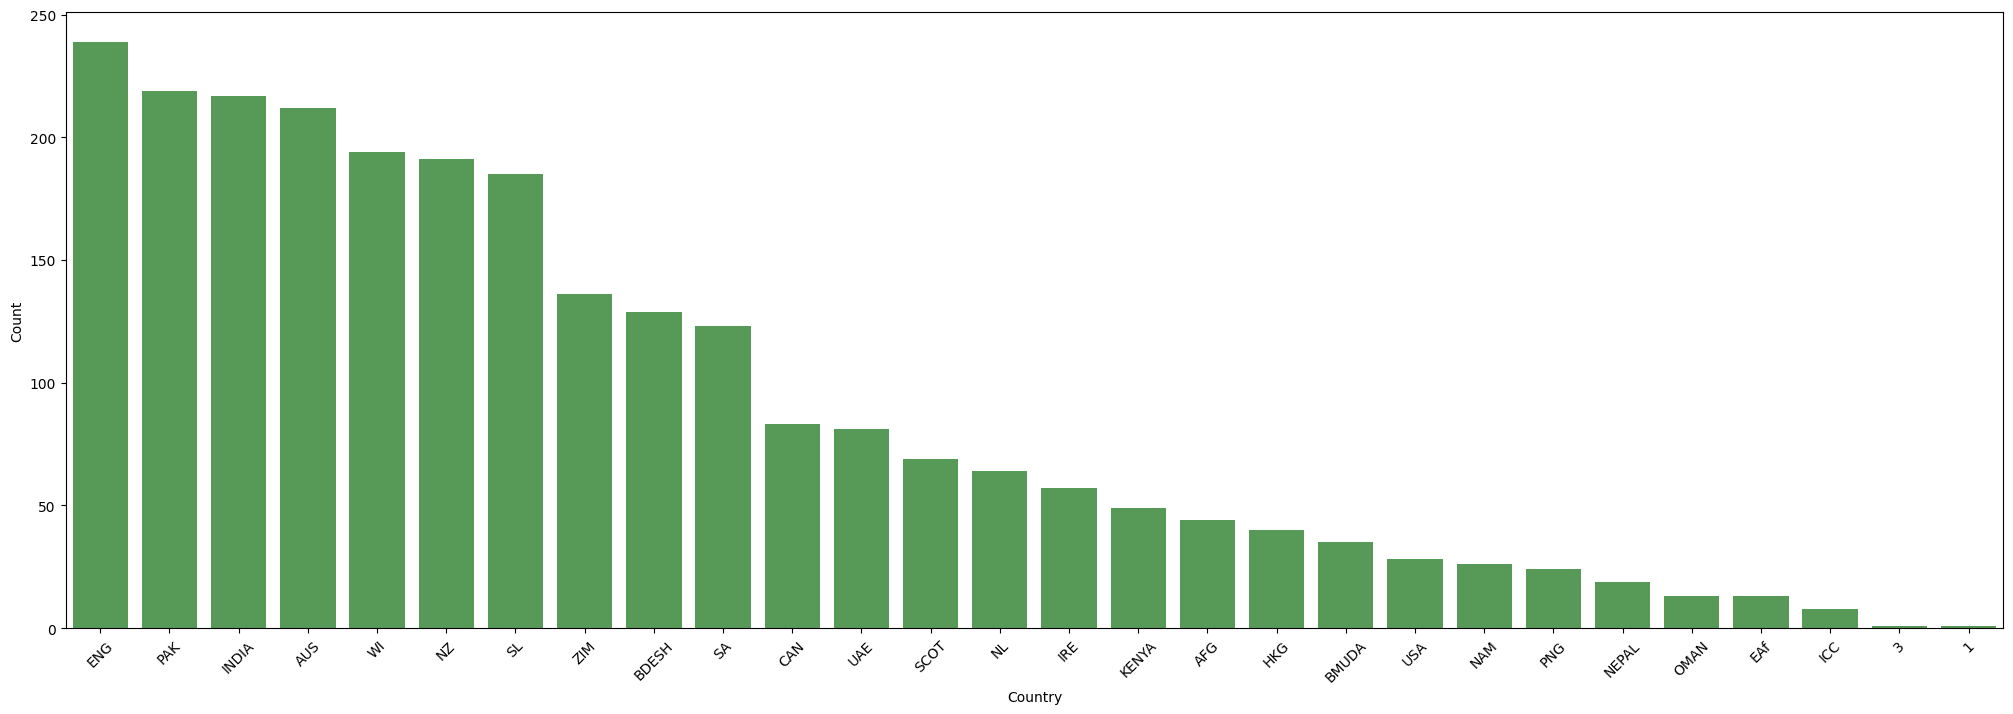

In [34]:
plt.figure(figsize=(25,8))
sns.barplot(x='Country',y='Count',data=country_count_df,color='green',alpha=0.7)
plt.xticks(rotation = 45,fontsize=10)

England has the most number of players followed by India & Pakistan

#Indian Players Analysis

In [35]:
indian_players=df_final[df_final['Country_name']=='INDIA']


Lets Analyse some interesting facts about Indian Team.

In [36]:
indian_players.describe()

,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Year_start,Year_end
count,217.000000,217.000000,217.000000,217.000000,217.000000,201.000000,217.000000,215.000000,217.000000,217.000000,217.000000,217.000000,217.000000
mean,49.829493,37.419355,7.506912,943.391705,49.525346,18.329851,1205.073733,67.501395,1.345622,5.129032,2.737327,1996.447005,2000.870968
std,77.025570,67.307986,11.873219,2394.653669,48.790278,12.788927,2910.175191,24.146441,5.475991,14.194807,4.126488,12.941757,12.932586
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,1974.000000,1974.000000
25%,4.000000,3.000000,1.000000,19.000000,10.000000,7.900000,30.000000,52.915000,0.000000,0.000000,0.000000,1986.000000,1991.000000
50%,16.000000,11.000000,2.000000,100.000000,32.000000,15.500000,162.000000,66.070000,0.000000,0.000000,1.000000,1998.000000,2001.000000
75%,57.000000,34.000000,9.000000,526.000000,77.000000,27.000000,713.000000,81.085000,0.000000,1.000000,3.000000,2007.000000,2012.000000
max,463.000000,452.000000,84.000000,18426.000000,264.000000,59.840000,21367.000000,177.270000,49.000000,96.000000,20.000000,2019.000000,2019.000000


In [37]:
indian_players[(indian_players['Year_start']==1974)]

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Year_start,Year_end,Country_name
150,SM Gavaskar (INDIA),108,102.0,14.0,3092.0,103.0,35.13,4966.0,62.26,1.0,27.0,8.0,1974,1987,INDIA
649,GR Viswanath (INDIA),25,23.0,1.0,439.0,75.0,19.95,830.0,52.89,0.0,2.0,1.0,1974,1982,INDIA
679,S Madan Lal (INDIA),67,35.0,14.0,401.0,53.0,19.09,645.0,62.17,0.0,1.0,1.0,1974,1987,INDIA
881,BP Patel (INDIA),10,9.0,1.0,243.0,82.0,30.37,399.0,60.90,0.0,1.0,0.0,1974,1979,INDIA
1191,FM Engineer (INDIA),5,4.0,1.0,114.0,54.0,38.00,195.0,58.46,0.0,1.0,0.0,1974,1975,INDIA
1287,S Abid Ali (INDIA),5,3.0,0.0,93.0,70.0,31.00,132.0,70.45,0.0,1.0,0.0,1974,1975,INDIA
1392,AL Wadekar (INDIA),2,2.0,0.0,73.0,67.0,36.50,90.0,81.11,0.0,1.0,0.0,1974,1974,INDIA
1525,S Venkataraghavan (INDIA),15,9.0,4.0,54.0,26.0,10.80,126.0,42.85,0.0,0.0,2.0,1974,1983,INDIA
1607,AV Mankad (INDIA),1,1.0,0.0,44.0,44.0,44.00,61.0,72.13,0.0,0.0,0.0,1974,1974,INDIA
1672,SS Naik (INDIA),2,2.0,0.0,38.0,20.0,19.00,68.0,55.88,0.0,0.0,0.0,1974,1974,INDIA


13 players played from 1974 . SM Gavaskar has the longest streak from 1974-1987

In [38]:
indian_players[(indian_players['SR']>100)]

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Year_start,Year_end,Country_name
27,V Sehwag (Asia/ICC/INDIA),251,245.0,9.0,8273.0,219.0,35.05,7929.0,104.33,15.0,38.0,14.0,1999,2013,INDIA
309,KM Jadhav (INDIA),71,50.0,18.0,1354.0,120.0,42.31,1325.0,102.18,2.0,6.0,2.0,2014,2019,INDIA
402,HH Pandya (INDIA),54,38.0,6.0,957.0,83.0,29.90,828.0,115.57,0.0,4.0,3.0,2016,2019,INDIA
453,YK Pathan (INDIA),57,41.0,11.0,810.0,123.0,27.00,713.0,113.60,2.0,3.0,7.0,2008,2012,INDIA
626,SS Iyer (INDIA),12,10.0,0.0,476.0,88.0,47.60,454.0,104.84,0.0,6.0,0.0,2017,2019,INDIA
730,RR Pant (INDIA),15,13.0,0.0,346.0,71.0,26.61,328.0,105.48,0.0,1.0,1.0,2018,2019,INDIA
1175,V Yadav (INDIA),19,12.0,2.0,118.0,34.0,11.80,116.0,101.72,0.0,0.0,2.0,1992,1994,INDIA
1559,ST Banerjee (INDIA),6,5.0,3.0,49.0,25.0,24.50,42.0,116.66,0.0,0.0,0.0,1991,1992,INDIA
1663,SN Thakur (INDIA),7,3.0,2.0,39.0,22.0,39.00,22.0,177.27,0.0,0.0,1.0,2017,2019,INDIA
1701,Joginder Sharma (INDIA),4,3.0,2.0,35.0,29.0,35.00,30.0,116.66,0.0,0.0,0.0,2004,2007,INDIA


Virendar Shewag has the strike rate > 100 and played more number of matches

In [42]:
indian_players.sort_values(by=['BF'],ascending=False)

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Year_start,Year_end,Country_name
0,SR Tendulkar (INDIA),463,452.0,41.0,18426.0,200.0,44.83,21367.0,86.23,49.0,96.0,20.0,1989,2012,INDIA
8,SC Ganguly (Asia/INDIA),311,300.0,23.0,11363.0,183.0,41.02,15416.0,73.70,22.0,72.0,16.0,1992,2007,INDIA
9,R Dravid (Asia/ICC/INDIA),344,318.0,40.0,10889.0,153.0,39.16,15284.0,71.24,12.0,83.0,13.0,1996,2011,INDIA
17,M Azharuddin (INDIA),334,308.0,54.0,9378.0,153.0,36.92,12669.0,74.02,7.0,58.0,9.0,1985,2000,INDIA
6,V Kohli (INDIA),242,233.0,39.0,11609.0,183.0,59.84,12445.0,93.28,43.0,55.0,13.0,2008,2019,INDIA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2418,S Tyagi (INDIA),4,1.0,1.0,1.0,1.0,NaN,2.0,50.00,0.0,0.0,0.0,2009,2010,INDIA
2358,SP Mukherjee (INDIA),3,1.0,1.0,2.0,2.0,NaN,2.0,100.00,0.0,0.0,0.0,1990,1991,INDIA
2421,J Yadav (INDIA),1,1.0,1.0,1.0,1.0,NaN,1.0,100.00,0.0,0.0,0.0,2016,2016,INDIA
2431,A Bhandari (INDIA),2,1.0,1.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,2000,2004,INDIA


In [55]:
debut_year=pd.DataFrame(indian_players['Year_start'].value_counts()).reset_index()
debut_year.columns=['Year','Count']
debut_year

,Year,Count
0,1974,13
1,2010,11
2,1999,9
3,1998,9
4,2016,9
5,1997,9
6,2002,8
7,2000,8
8,1988,7
9,2004,6


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44],
 [Text(0, 0, '1974'),
  Text(1, 0, '1975'),
  Text(2, 0, '1976'),
  Text(3, 0, '1978'),
  Text(4, 0, '1979'),
  Text(5, 0, '1980'),
  Text(6, 0, '1981'),
  Text(7, 0, '1982'),
  Text(8, 0, '1983'),
  Text(9, 0, '1984'),
  Text(10, 0, '1985'),
  Text(11, 0, '1986'),
  Text(12, 0, '1987'),
  Text(13, 0, '1988'),
  Text(14, 0, '1989'),
  Text(15, 0, '1990'),
  Text(16, 0, '1991'),
  Text(17, 0, '1992'),
  Text(18, 0, '1993'),
  Text(19, 0, '1994'),
  Text(20, 0, '1995'),
  Text(21, 0, '1996'),
  Text(22, 0, '1997'),
  Text(23, 0, '1998'),
  Text(24, 0, '1999'),
  Text(25, 0, '2000'),
  Text(26, 0, '2001'),
  Text(27, 0, '2002'),
  Text(28, 0, '2003'),
  Text(29, 0, '2004'),
  Text(30, 0, '2005'),
  Text(31, 0, '2006'),
  Text(32, 0,

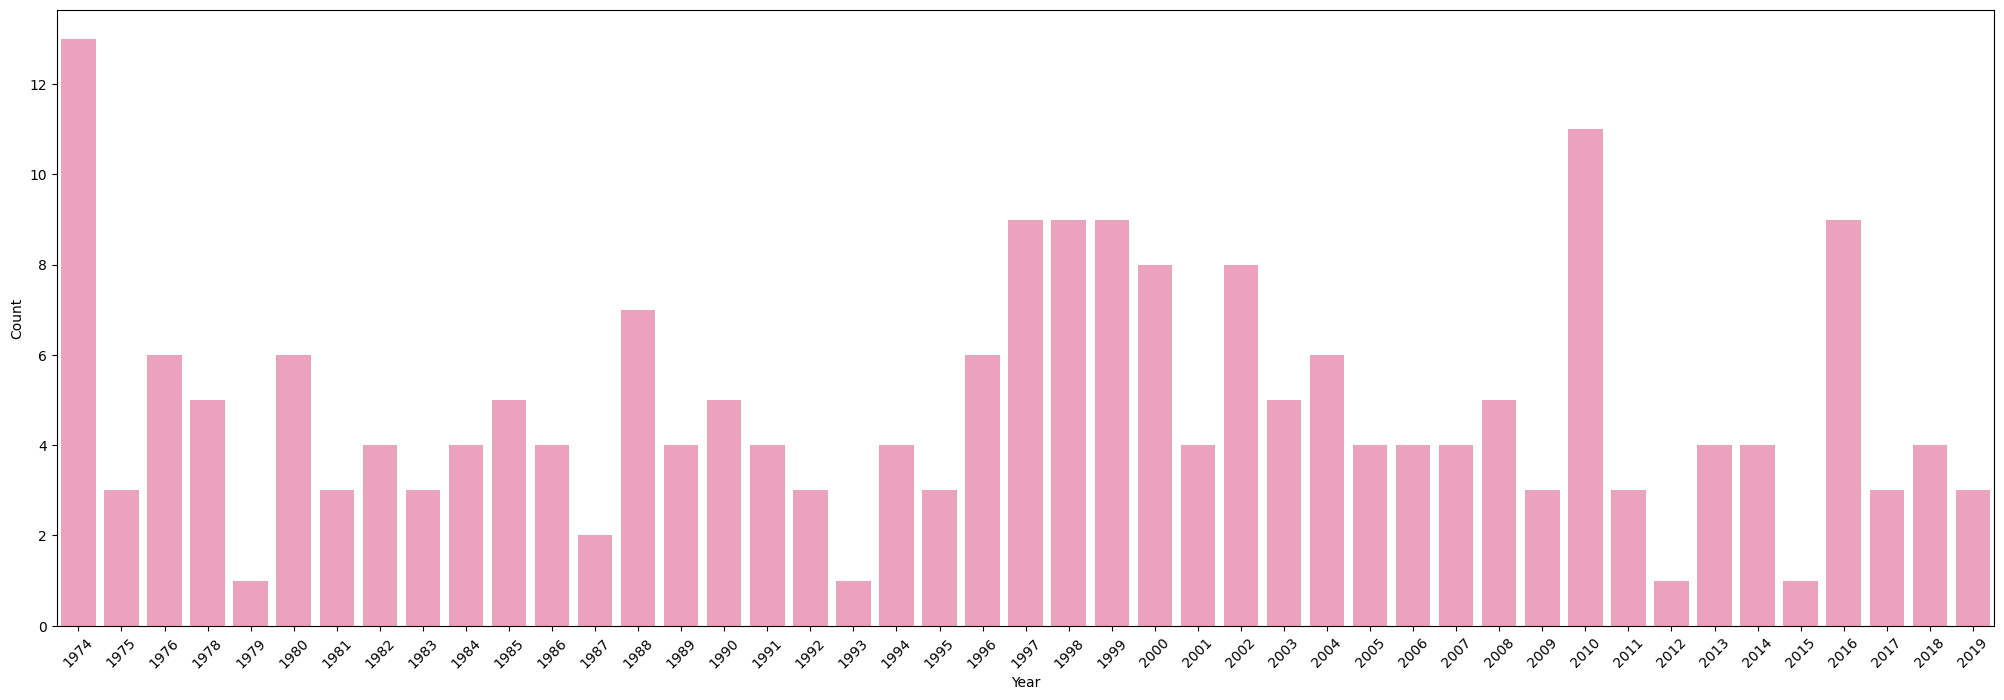

In [56]:
plt.figure(figsize=(25,8))
sns.barplot(x='Year',y='Count',data=debut_year,color='#f46a9b',alpha=0.7)
plt.xticks(rotation = 45,fontsize=10)

In [73]:
indian_players[indian_players['Runs']<=600]

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Year_start,Year_end,Country_name
551,SB Joshi (INDIA),69,45.0,11.0,584.0,61.0,17.17,653.0,89.43,0.0,1.0,4.0,1996,2001,INDIA
565,KS More (INDIA),94,65.0,22.0,563.0,42.0,13.09,808.0,69.67,0.0,0.0,5.0,1984,1993,INDIA
586,B Kumar (INDIA),114,52.0,15.0,526.0,53.0,14.21,703.0,74.82,0.0,1.0,8.0,2012,2019,INDIA
593,PK Amre (INDIA),37,30.0,5.0,513.0,84.0,20.52,799.0,64.20,0.0,2.0,1.0,1991,1994,INDIA
626,SS Iyer (INDIA),12,10.0,0.0,476.0,88.0,47.60,454.0,104.84,0.0,6.0,0.0,2017,2019,INDIA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2422,NS Yadav (INDIA),7,2.0,2.0,1.0,1.0,NaN,16.0,6.25,0.0,0.0,0.0,1986,1987,INDIA
2423,B Yograj Singh (INDIA),6,4.0,2.0,1.0,1.0,0.50,12.0,8.33,0.0,0.0,1.0,1980,1981,INDIA
2431,A Bhandari (INDIA),2,1.0,1.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,2000,2004,INDIA
2463,AM Nayar (INDIA),3,1.0,1.0,0.0,0.0,NaN,7.0,0.00,0.0,0.0,0.0,2009,2009,INDIA


We can observe that nearly 165 players are there  who scored below 600 runs.

In [80]:
high_rated_players=indian_players[(indian_players['Runs']>=3000) & (indian_players['SR']>=80)]

Let us simply set a benchmark like players who have scored more than 3000 runs at the strike rate of 80+

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'SR Tendulkar (INDIA)'),
  Text(1, 0, 'V Kohli (INDIA)'),
  Text(2, 0, 'MS Dhoni (Asia/INDIA)'),
  Text(3, 0, 'RG Sharma (INDIA)'),
  Text(4, 0, 'Yuvraj Singh (Asia/INDIA)'),
  Text(5, 0, 'V Sehwag (Asia/ICC/INDIA)'),
  Text(6, 0, 'SK Raina (INDIA)'),
  Text(7, 0, 'S Dhawan (INDIA)'),
  Text(8, 0, 'G Gambhir (INDIA)'),
  Text(9, 0, 'N Kapil Dev (INDIA)')])

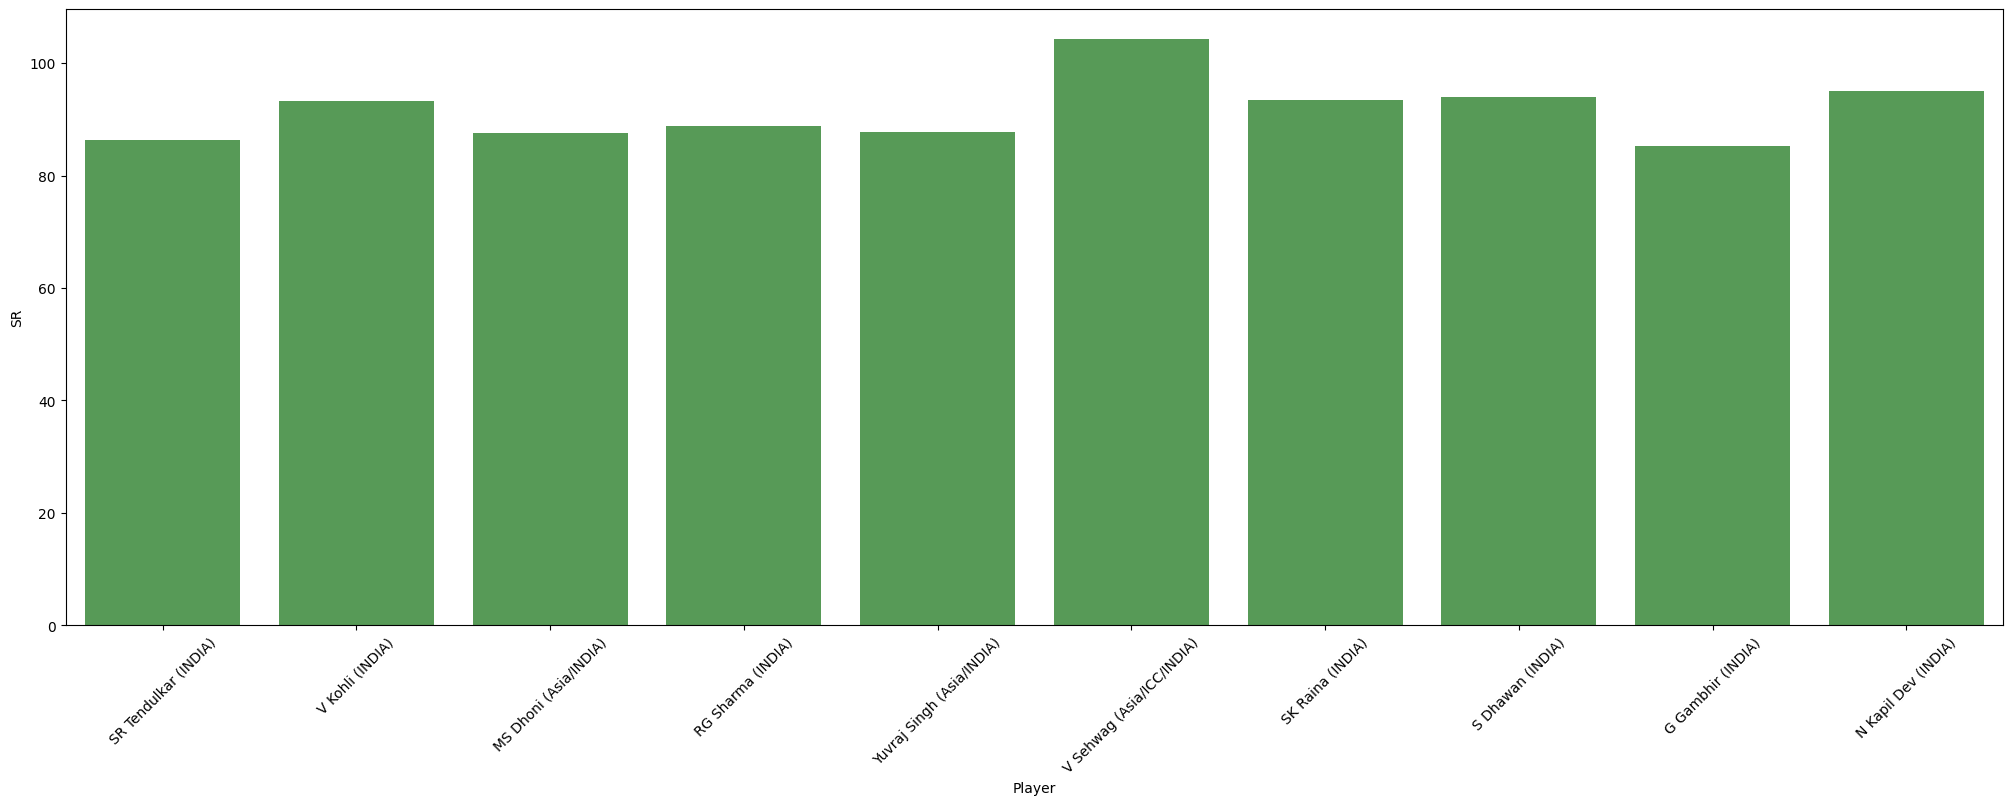

In [83]:
plt.figure(figsize=(25,8))
sns.barplot(x='Player',y='SR',data=high_rated_players,color='green',alpha=0.7)
plt.xticks(rotation = 45,fontsize=10)

let us check the innings taken to score a century by the indian players

In [94]:
indian_players['Century_rate']=indian_players['Inns']/indian_players['100']
indian_players.head()

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Year_start,Year_end,Country_name,Century_rate
6,V Kohli (INDIA),242,233.0,39.0,11609.0,183.0,59.84,12445.0,93.28,43.0,55.0,13.0,2008,2019,INDIA,5.418605
19,RG Sharma (INDIA),221,214.0,32.0,8944.0,264.0,49.14,10063.0,88.88,28.0,43.0,13.0,2007,2019,INDIA,7.642857
73,S Dhawan (INDIA),133,131.0,7.0,5518.0,143.0,44.50,5869.0,94.01,17.0,27.0,5.0,2010,2019,INDIA,7.705882
420,KL Rahul (INDIA),26,25.0,4.0,889.0,111.0,42.33,1098.0,80.96,3.0,5.0,2.0,2016,2019,INDIA,8.333333
0,SR Tendulkar (INDIA),463,452.0,41.0,18426.0,200.0,44.83,21367.0,86.23,49.0,96.0,20.0,1989,2012,INDIA,9.224490


In [105]:
indian_players_century_rate = indian_players.sort_values(by='Century_rate', ascending=True,key=lambda col: col.replace([np.inf, -np.inf], np.nan))
indian_players_century_rate1=indian_players_century_rate.head(38)
indian_players_century_rate1

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Year_start,Year_end,Country_name,Century_rate
6,V Kohli (INDIA),242,233.0,39.0,11609.0,183.0,59.84,12445.0,93.28,43.0,55.0,13.0,2008,2019,INDIA,5.418605
19,RG Sharma (INDIA),221,214.0,32.0,8944.0,264.0,49.14,10063.0,88.88,28.0,43.0,13.0,2007,2019,INDIA,7.642857
73,S Dhawan (INDIA),133,131.0,7.0,5518.0,143.0,44.50,5869.0,94.01,17.0,27.0,5.0,2010,2019,INDIA,7.705882
420,KL Rahul (INDIA),26,25.0,4.0,889.0,111.0,42.33,1098.0,80.96,3.0,5.0,2.0,2016,2019,INDIA,8.333333
0,SR Tendulkar (INDIA),463,452.0,41.0,18426.0,200.0,44.83,21367.0,86.23,49.0,96.0,20.0,1989,2012,INDIA,9.224490
803,MK Tiwary (INDIA),12,12.0,1.0,287.0,104.0,26.09,403.0,71.21,1.0,1.0,0.0,2008,2015,INDIA,12.000000
79,G Gambhir (INDIA),147,143.0,11.0,5238.0,150.0,39.68,6144.0,85.25,11.0,34.0,11.0,2003,2013,INDIA,13.000000
8,SC Ganguly (Asia/INDIA),311,300.0,23.0,11363.0,183.0,41.02,15416.0,73.70,22.0,72.0,16.0,1992,2007,INDIA,13.636364
199,VVS Laxman (INDIA),86,83.0,7.0,2338.0,131.0,30.76,3282.0,71.23,6.0,10.0,3.0,1998,2006,INDIA,13.833333
27,V Sehwag (Asia/ICC/INDIA),251,245.0,9.0,8273.0,219.0,35.05,7929.0,104.33,15.0,38.0,14.0,1999,2013,INDIA,16.333333


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37],
 [Text(0, 0, 'V Kohli (INDIA)'),
  Text(1, 0, 'RG Sharma (INDIA)'),
  Text(2, 0, 'S Dhawan (INDIA)'),
  Text(3, 0, 'KL Rahul (INDIA)'),
  Text(4, 0, 'SR Tendulkar (INDIA)'),
  Text(5, 0, 'MK Tiwary (INDIA)'),
  Text(6, 0, 'G Gambhir (INDIA)'),
  Text(7, 0, 'SC Ganguly (Asia/INDIA)'),
  Text(8, 0, 'VVS Laxman (INDIA)'),
  Text(9, 0, 'V Sehwag (Asia/ICC/INDIA)'),
  Text(10, 0, 'AT Rayudu (INDIA)'),
  Text(11, 0, 'MK Pandey (INDIA)'),
  Text(12, 0, 'Yuvraj Singh (Asia/INDIA)'),
  Text(13, 0, 'YK Pathan (INDIA)'),
  Text(14, 0, 'NS Sidhu (INDIA)'),
  Text(15, 0, 'KM Jadhav (INDIA)'),
  Text(16, 0, 'R Dravid (Asia/ICC/INDIA)'),
  Text(17, 0, 'WV Raman (INDIA)'),
  Text(18, 0, 'AM Rahane (INDIA)'),
  Text(19, 0, 'MS Dhoni (Asia/INDIA)'),
  Text(20, 0, 'A Jadeja (INDIA)'),
  Te

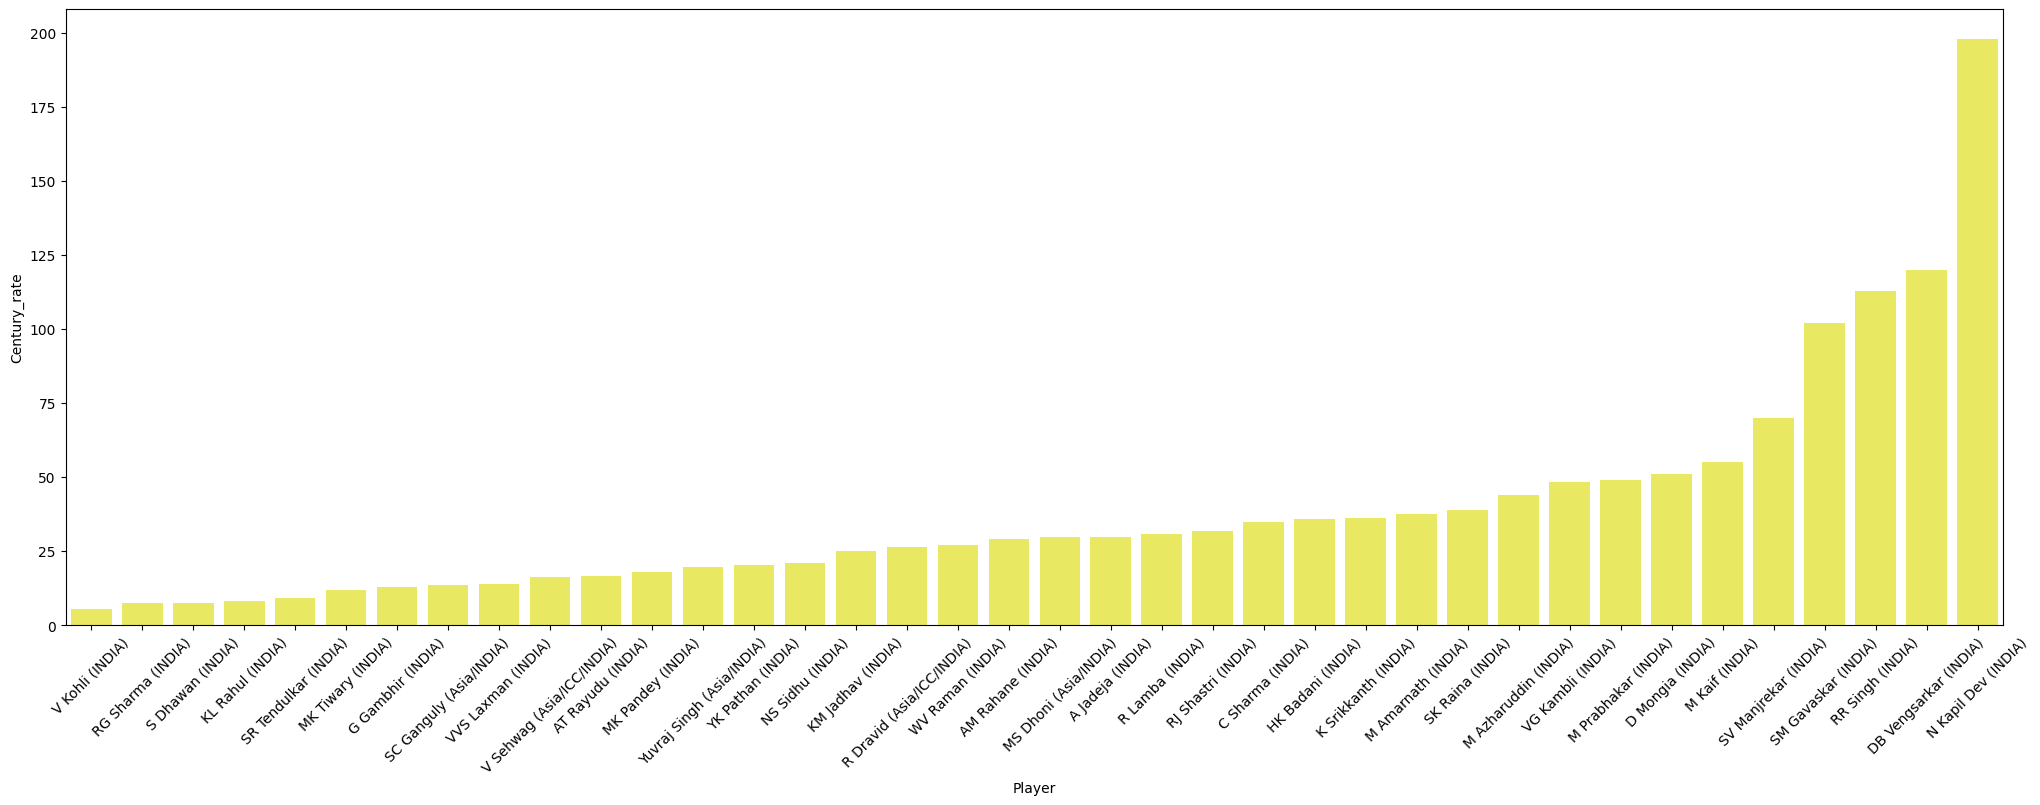

In [106]:
plt.figure(figsize=(25,8))
sns.barplot(x='Player',y='Century_rate',data=indian_players_century_rate1,color='Yellow',alpha=0.7)
plt.xticks(rotation = 45,fontsize=10)